### 史塔克財金工作室 進階班  

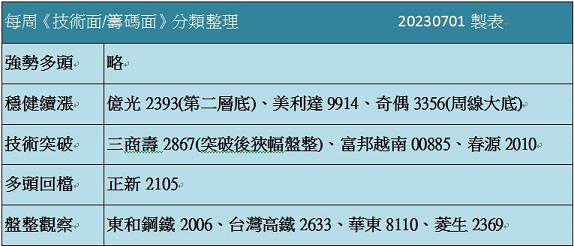  
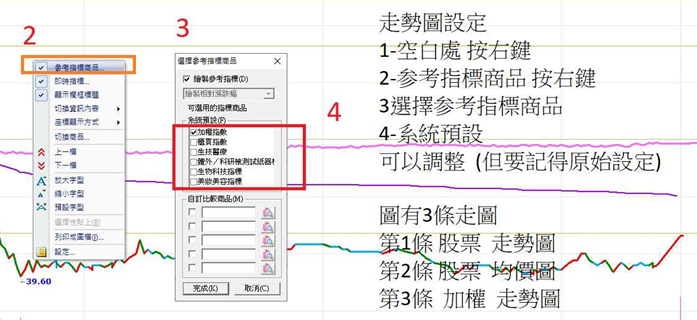  
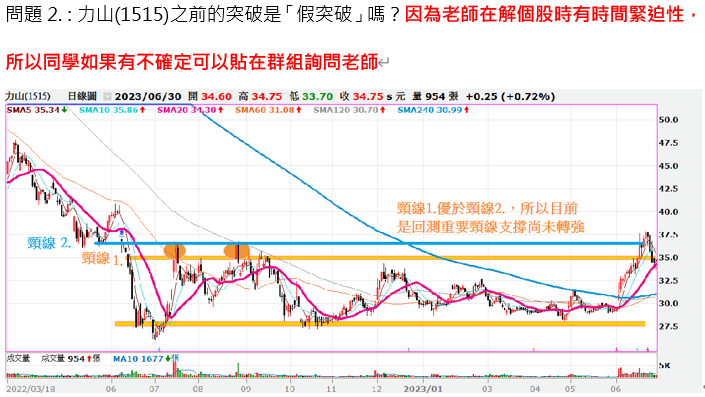  
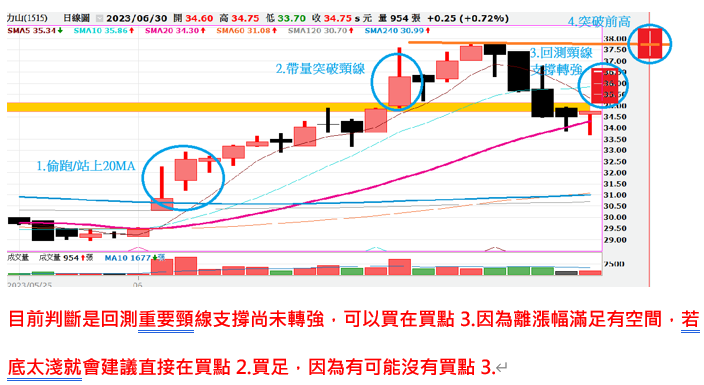  
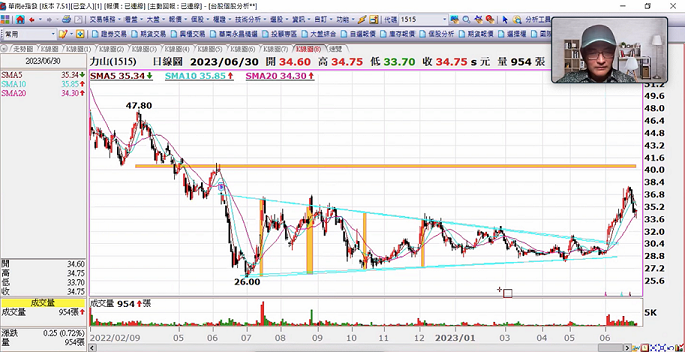

[記帳真的是很重要](https://tinyurl.com/4w75d872)，我自己不早不晚，大概從19歲開始有記帳習慣，大約是大學二年級。  
只是隨著時間的演進，記帳習慣從一開始的紀錄流水帳，中間歷經很多演化，後來到現只用不同的帳戶管理，例如：生活帳戶、儲蓄帳戶、短期投資帳戶、長期投資帳戶。  
要選擇哪一種記帳方式都行，但真的必須要有對自己收入和支出，有清楚的輪廓，這是投資理財的關鍵第一步。  
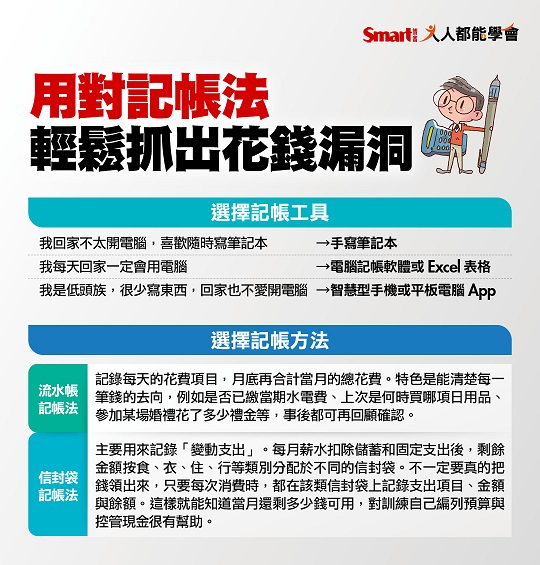  

### 【[周末影音解盤](https://tinyurl.com/3n4vakyc)】弱勢盤整，支撐有守  
歐美股市短線轉強，為何台股無法跟進表現？  
指數弱勢陷入膠著的盤整，空方與多方，哪一邊的條件較多？  
未來中期空方轉折的重點，要留意那兩個關鍵指標？  
完整內容請參考2023/07/02影音解盤~  
https://www.youtube.com/watch?v=58VJr2IAmAc

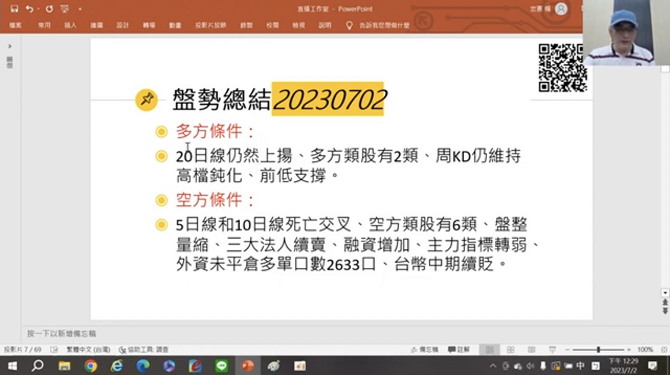  
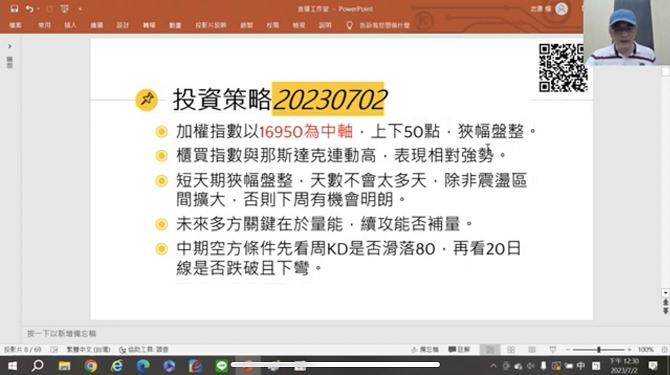  

### 本日進度  
  
* 力山(1515)現持有1張(**目前規劃僅試單1張**)。  

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import mplfinance as mpf
import numpy as np
from scipy.signal import argrelextrema

In [2]:
##### 使用2022年1月24日到2023年6月30日之日線圖資料 #####

# 載入從「好神通PLUS」輸出的Excel檔
df = pd.read_excel('./data/SINO_1515_230630.xlsx')

# 保存K棒的基本資訊(開、高、低、收、量)
df_k_line = df.drop(columns=['SMA5','SMA10','SMA20','SMA60','SMA120','SMA240','MA5','MA10'])

# 保存價的均線
df_sma = df.drop(columns=['開盤價','最高價','最低價','收盤價','成交量','MA5','MA10']) 

# 將K棒的Columns的名稱由中文改為英文
df_k_line = df_k_line.rename(columns={'時間':'Date','開盤價':'Open','最高價':'High','最低價':'Low','收盤價':'Close','成交量':'Volume'})

# 將價的均線的Columns的名稱由中文改為英文
df_sma = df_sma.rename(columns={'時間':'Date'})

# 設定今天日期
today_date = df_k_line.iloc[-1]['Date'].strftime("%Y-%m-%d")

# 將K棒的Date設為Index
df_k_line.set_index(df_k_line['Date'],inplace=True)
df_k_line = df_k_line.drop(columns=['Date'])

# 將價的均線的Date設為Index
df_sma.set_index(df_sma['Date'],inplace=True)
df_sma = df_sma.drop(columns=['Date'])

頸線價格 ＝ 35.00元 ， 開始日期 ＝ 2022-06-06 ， 結束日期 ＝ 2023-06-30
目標價 ＝ 42.50元


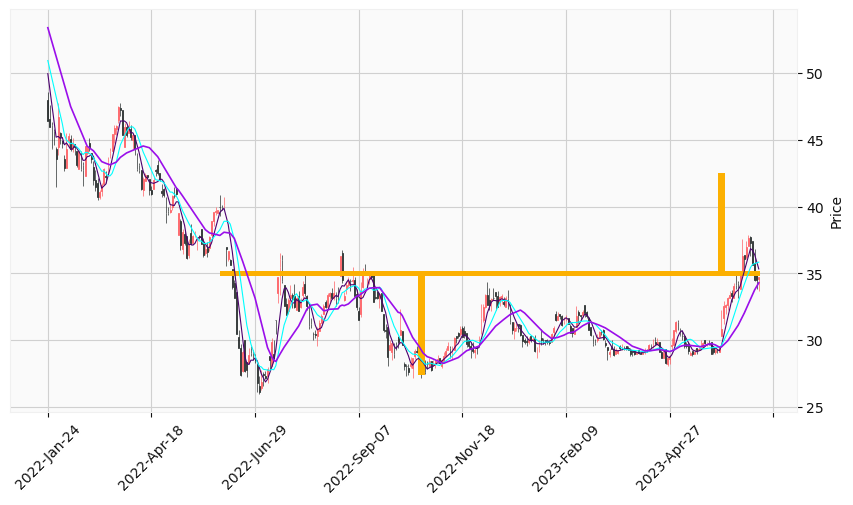

In [3]:
# 手動設定頸線 - 參照前述 「史塔克財金工作室 進階班」 之資訊重新設定『頸線1』
neckline_price = df_k_line.loc['2022-9-13']['Open']
neckline_start_date = '2022-06-06'
neckline_end_date = today_date
print('頸線價格 ＝ {:.2f}元 ， 開始日期 ＝ {} ， 結束日期 ＝ {}'.format(neckline_price,neckline_start_date,neckline_end_date))

# 估算目標價
bottom_price_date = '2022-10-21'
bottom_price = df_k_line.loc[bottom_price_date]['Close']
target_price = (neckline_price - bottom_price) + neckline_price
print('目標價 ＝ {:.2f}元'.format(target_price))
target_price_date = '2023-06-02'

# 設定K線格式
mc = mpf.make_marketcolors(up='xkcd:light red', down='xkcd:almost black', inherit=True)
s  = mpf.make_mpf_style(base_mpf_style='yahoo', marketcolors=mc)

# 設定頸線
seq_of_seq_of_points=[
    [(neckline_start_date,neckline_price),(neckline_end_date,neckline_price)],
    [(bottom_price_date,bottom_price),(bottom_price_date,neckline_price)],
    [(target_price_date,target_price),(target_price_date,neckline_price)]
    
                     ]

# 設定均線
added_plots={
    "SMA5": mpf.make_addplot(df_sma['SMA5'],width=0.8,color='xkcd:royal purple'),
    "SMA10": mpf.make_addplot(df_sma['SMA10'],width=0.8,color='xkcd:cyan'),
    "SMA20": mpf.make_addplot(df_sma['SMA20'],width=1.2,color='xkcd:violet')
            }

# 繪出K線圖
kwargs = dict(type='candle', style=s, figratio=(19,10), addplot=list(added_plots.values()),alines=dict(alines=seq_of_seq_of_points, linewidths=(2.5,5,5), colors=('xkcd:yellow orange')))
mpf.plot(df_k_line,**kwargs)

In [4]:
# 來源 ： https://github.com/neurotrader888/TechnicalAnalysisAutomation/blob/main/rolling_window.py
# 參考 ： https://www.youtube.com/watch?v=X31hyMhB-3s

# Checks if there is a local top detected at curr index
def rw_top(data: np.array, curr_index: int, order: int) -> bool:
    if curr_index < order * 2 + 1:
        return False

    top = True
    k = curr_index - order
    v = data[k]
    for i in range(1, order + 1):
        if data[k + i] > v or data[k - i] > v:
            top = False
            break
    
    return top

# Checks if there is a local top detected at curr index
def rw_bottom(data: np.array, curr_index: int, order: int) -> bool:
    if curr_index < order * 2 + 1:
        return False

    bottom = True
    k = curr_index - order
    v = data[k]
    for i in range(1, order + 1):
        if data[k + i] < v or data[k - i] < v:
            bottom = False
            break
    
    return bottom

def rw_extremes(data: np.array, order:int):
    # Rolling window local tops and bottoms
    tops = []
    bottoms = []
    for i in range(len(data)):
        if rw_top(data, i, order):
            # top[0] = confirmation index
            # top[1] = index of top
            # top[2] = price of top
            top = [i, i - order, data[i - order]]
            tops.append(top)
        if rw_bottom(data, i, order):
            # bottom[0] = confirmation index
            # bottom[1] = index of bottom
            # bottom[2] = price of bottom
            bottom = [i, i - order, data[i - order]]
            bottoms.append(bottom)
    return tops, bottoms

In [5]:
##### 尋找轉折點函式 #####
# prices         : 價格 (DataFrame)
# mode           : 模式 (str)
# order          : 最小化過濾器的距離參數，最小峰值寬度ｍｉｎ＿ｗｉｄｔｈ＝ｏｒｄｅｒ＊２＋１ (int)
# smoothing      : 平滑化參數 （當模式為'close'時有效） (int)
# real_body      : 以實體為主，轉折點會因波峰或波谷的狀況而選擇地使用開盤價 （當模式為'close'時有效） (bool)
# rolling_window : 使用neurotrader的"Rolling Window"方式尋找轉折點 (bool)
def FindingTurningPoints(prices, mode = 'close', order = 1, smoothing = 1,real_body = False,rolling_window = False) :
    # 價格資料確認與處理
    if prices is None and type(prices) is not DataFrame:
        return None
    in_prices = prices.copy()
    if 'Open' not in in_prices.columns or 'High' not in in_prices.columns or 'Low' not in in_prices.columns or 'Close' not in in_prices.columns :
        return None    
    if 'Date' not in in_prices.columns and in_prices.index.dtype == 'datetime64[ns]' :
        in_prices.index.name = 'Date'
        in_prices = in_prices.reset_index()
    if 'Date' not in in_prices.columns :
        return None
    # 模式確認與處理
    if mode == 'high_low' :
        prices_high=np.array(in_prices['High'])
        prices_low=np.array(in_prices['Low'])
    elif mode == 'close' :
        if smoothing > 1 :
            # 若為平滑化的收盤價,使用向前與向後傳播非空值的方法填充空(NaN)值;並將窗口標籤設置為窗口索引的中心，以正確反映趨勢
            smooth_close_prices = np.array(in_prices['Close'].rolling(window=smoothing,center=True).mean().fillna(method='bfill').fillna(method='ffill'))
            prices_high=smooth_close_prices
            prices_low=smooth_close_prices
        else :
            prices_close=np.array(in_prices['Close'])
            prices_high=prices_close
            prices_low=prices_close
    else :
        return None
    if len(prices_high) != len(prices_low) :
        return None
    total_price = len(prices_high)
    # 找出轉折點，並保存其索引
    if rolling_window is True :
        _,local_min = rw_extremes(prices_low,order)
        local_max,_ = rw_extremes(prices_high,order)
        local_min = np.array(local_min)
        local_max = np.array(local_max)
        local_min_idx = local_min[:,1]
        local_max_idx = local_max[:,1]
    else :
        local_min_idx = argrelextrema(prices_low,np.less,order=order)[0]
        local_max_idx = argrelextrema(prices_high,np.greater,order=order)[0]
        local_min_idx = np.array(local_min_idx)
        local_max_idx = np.array(local_max_idx)
    # 合併局部最大(波峰)與局部最小(波谷)轉折點
    local_max_min_point=[]
    point_type = ''
    for idx in range(total_price):
        if idx in local_max_idx :
            if point_type != 'HI' :
                # 波谷轉波峰
                point_type = 'HI'
                if mode == 'high_low' :
                    local_max_min_point.append((idx,in_prices.iloc[idx]['Date'],in_prices.iloc[idx]['High'],point_type))
                elif mode == 'close' :
                    real_body_price = in_prices.iloc[idx]['Close']
                    if real_body is True and in_prices.iloc[idx]['Open'] > in_prices.iloc[idx]['Close'] :
                        real_body_price = in_prices.iloc[idx]['Open']
                    local_max_min_point.append((idx,in_prices.iloc[idx]['Date'],real_body_price,point_type))
            else :
                # 同為波峰，選最高者
                previous_price = local_max_min_point[-1][2]
                if mode == 'high_low' :
                    current_price = in_prices.iloc[idx]['High']
                    if current_price > previous_price :
                        # 移除前一筆
                        previous_point = local_max_min_point.pop()
                        # 新增目前這一筆
                        local_max_min_point.append((idx,in_prices.iloc[idx]['Date'],in_prices.iloc[idx]['High'],point_type))
                elif mode == 'close' :
                    current_price = in_prices.iloc[idx]['Close']
                    if current_price > previous_price :
                        # 移除前一筆
                        previous_point = local_max_min_point.pop()
                        # 新增目前這一筆
                        real_body_price = in_prices.iloc[idx]['Close']
                        if real_body is True and in_prices.iloc[idx]['Open'] > in_prices.iloc[idx]['Close'] :
                            real_body_price = in_prices.iloc[idx]['Open']
                        local_max_min_point.append((idx,in_prices.iloc[idx]['Date'],real_body_price,point_type))
        elif idx in local_min_idx :
            if point_type != 'LO' :
                # 波峰轉波谷
                point_type = 'LO'
                if mode == 'high_low' :
                    local_max_min_point.append((idx,in_prices.iloc[idx]['Date'],in_prices.iloc[idx]['Low'],point_type))
                elif mode == 'close' :
                    real_body_price = in_prices.iloc[idx]['Close']
                    if real_body is True and in_prices.iloc[idx]['Open'] < in_prices.iloc[idx]['Close'] :
                        real_body_price = in_prices.iloc[idx]['Open']
                    local_max_min_point.append((idx,in_prices.iloc[idx]['Date'],real_body_price,point_type))
            else :
                # 同為波谷，選最低者
                previous_price = local_max_min_point[-1][2]
                if mode == 'high_low' :
                    current_price = in_prices.iloc[idx]['Low']
                    if current_price < previous_price :
                        # 移除前一筆
                        previous_point = local_max_min_point.pop()
                        # 改新增目前這一筆
                        local_max_min_point.append((idx,in_prices.iloc[idx]['Date'],in_prices.iloc[idx]['Low'],point_type))
                elif mode == 'close' :
                    current_price = in_prices.iloc[idx]['Close']
                    if current_price < previous_price :
                        # 移除前一筆
                        previous_point = local_max_min_point.pop()
                        # 改新增目前這一筆
                        real_body_price = in_prices.iloc[idx]['Close']
                        if real_body is True and in_prices.iloc[idx]['Open'] < in_prices.iloc[idx]['Close'] :
                            real_body_price = in_prices.iloc[idx]['Open']
                        local_max_min_point.append((idx,in_prices.iloc[idx]['Date'],real_body_price,point_type))
    local_max_min_point = pd.DataFrame(local_max_min_point,columns=['DateIndex','Date','Price','Type'])
    # 轉換為輸出格式
    max_min = local_max_min_point.set_index('DateIndex')
    return local_min_idx,local_max_idx,max_min

                Date  Price Type
DateIndex                       
5         2022-02-09  46.75   HI
24        2022-03-09  40.75   LO
34        2022-03-23  47.45   HI
67        2022-05-12  36.15   LO
85        2022-06-08  40.10   HI
102       2022-07-01  26.10   LO
112       2022-07-15  36.05   HI
129       2022-08-09  30.40   LO
141       2022-08-25  36.30   HI
150       2022-09-07  31.50   LO
152       2022-09-12  34.90   HI
180       2022-10-21  27.50   LO
211       2022-12-05  33.40   HI
235       2023-01-09  29.20   LO
258       2023-02-21  32.10   HI
298       2023-04-25  28.30   LO
303       2023-05-03  31.35   HI
320       2023-05-26  28.95   LO
338       2023-06-21  37.65   HI


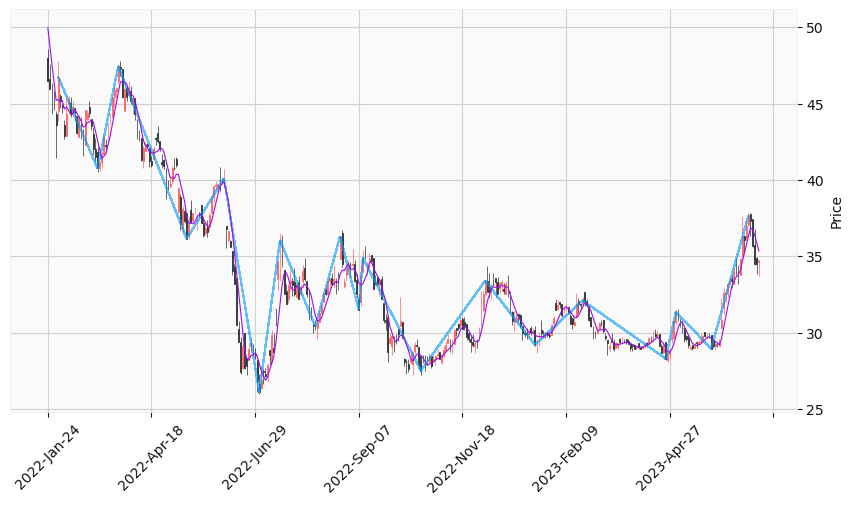

In [6]:
# 尋找轉折點
_,_,max_min = FindingTurningPoints(df_k_line,'close',order=10,real_body=True)
print(max_min)

# 設定K線格式
mc = mpf.make_marketcolors(up='xkcd:light red', down='xkcd:almost black', inherit=True)
s  = mpf.make_mpf_style(base_mpf_style='yahoo', marketcolors=mc)

# 設定轉折線
seq_of_seq_of_points = []
for _current in range(0,len(max_min)) :
    _next = _current + 1
    if _next < len(max_min) :
        seq_of_seq_of_points.append([(max_min.iloc[_current]['Date'],max_min.iloc[_current]['Price']),(max_min.iloc[_next]['Date'],max_min.iloc[_next]['Price'])])
    else :
        break
        
# 設定均線
added_plots={
    "SMA5": mpf.make_addplot(df_sma['SMA5'],width=0.8,color='xkcd:violet')
            }

# 繪出K線圖
kwargs = dict(type='candle', style=s, figratio=(19,10), addplot=list(added_plots.values()),alines=dict(alines=seq_of_seq_of_points, linewidths=1, colors='xkcd:azure', alpha=0.6))
mpf.plot(df_k_line,**kwargs)